In [2]:
import pandas as pd 
from sklearn.metrics import f1_score, brier_score_loss
import numpy as np
pd.set_option("display.max_columns", None)

In [4]:
modes = ["bal", "unbal1", "unbal2", "adj"]
markers = {"bal": "o", "unbal1": "s", "unbal2": "D", "adj": "^"}

In [ ]:
data = pd.read_csv(f"data/all_labels_full.csv")

### Original data percentage evaluation and plots

In [5]:
# first step, get raw data into results
import pandas as pd
SEEDs = [10,42,512,1010,3344]
for seed in SEEDs:
    # Initialize CSV file with the desired columns
    output_file = f'results/results_data_{seed}.csv'
    columns = ['L', 'X', "mode",'a_bias', 'b_bias', 'simulations', 'len_data']
    df = pd.DataFrame(columns=columns)
    df.to_csv(output_file, index=False)

    modes=['bal', 'unbal1', 'unbal2', 'adj']

    # Iterate over values of L and X and append results to the CSV file
    for L in ["hs", "ol"]:
        for X in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:#, 0.35, 0.4]:#, 0.45, 0.5]:
            for mode in modes:
                # Load the data
                data = pd.read_csv(f"data/all_labels_full.csv")
                data = data[(data['dataset'] == mode) & (data['x'] == X)]


                # Calculate biases and other metrics
                a_bias = (data["lab_source"] == "A").sum() / len(data["lab_source"])
                b_bias = (data["lab_source"] == "B").sum() / len(data["lab_source"])
                simulations = (data[f"new_{L}"] == 1).sum() / len(data["lab_source"])
                if L == "hs":
                    gold = (data["hs"] == 1).sum() / len(data["lab_source"])
                else:
                    gold = (data["ol"] == 1).sum() / len(data["lab_source"])
                len_data = len(data["lab_source"])

                # Prepare the new row
                new_row = {
                    'L': L, 'X': X, "mode": mode,
                    'a_bias': a_bias*100, 'b_bias': b_bias*100,
                    'simulations': simulations*100, 'len_data': len_data
                }

                # Convert the row to a DataFrame and append to CSV
                df = pd.DataFrame([new_row])
                df.to_csv(output_file, mode='a', header=False, index=False)

In [6]:
# Step 2: get results averaged over seeds
import pandas as pd
import glob

# File paths: assume all result CSV files are stored in one folder
file_paths = glob.glob("results/*.csv")

# Read all CSV files into a list (only those containing "results_data" in filename)
dfs = [pd.read_csv(file) for file in file_paths if "results_data" in file]

# Make sure all DataFrames have the same column structure
for i, df in enumerate(dfs):
    if not dfs[0].columns.equals(df.columns):
        raise ValueError(f"The columns of CSV file {i+1} do not match the first file")

# Columns to be averaged
columns_to_average = ["a_bias", "b_bias", "simulations", "len_data"]

# Other columns that should not be averaged
all_other_columns = [col for col in dfs[0].columns if col not in columns_to_average]

# Lists to store intermediate results
average_data = []
non_average_data = []

# Extract required columns from each file
for df in dfs:
    average_data.append(df[columns_to_average])
    non_average_data.append(df[all_other_columns])

# Combine columns that need averaging
average_combined = pd.concat(average_data)

# Compute mean values grouped by row index (same rows across seeds)
average_result = average_combined.groupby(average_combined.index).mean()

# Extract other columns (assumed identical across files)
non_average_result = non_average_data[0]  # keep non-averaged columns from the first file

# Merge averaged columns with other columns
final_result = pd.concat(
    [non_average_result.reset_index(drop=True), average_result.reset_index(drop=True)],
    axis=1
)

# Save to a new CSV file
final_result.to_csv("results/final_results_with_averages_original.csv", index=False)

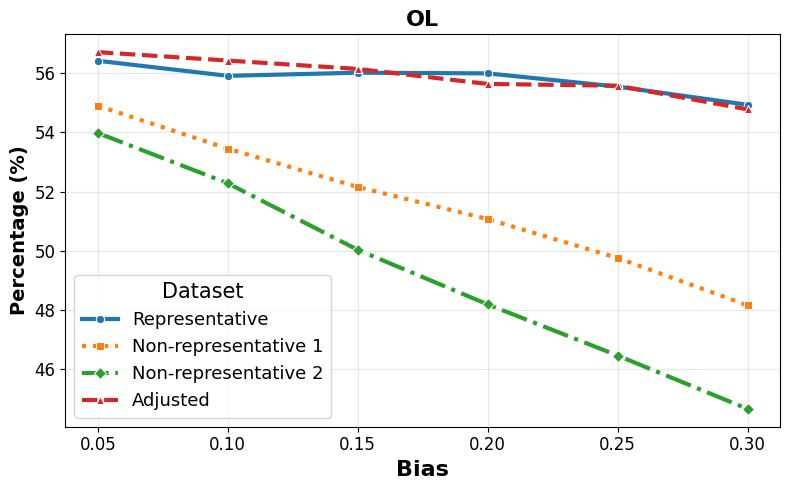

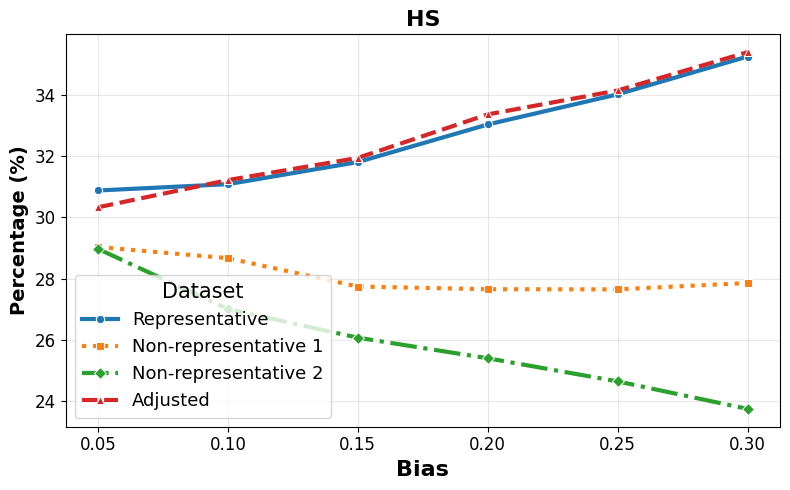

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("results/final_results_with_averages_original.csv")

# Filter and map mode names for better readability
mode2name = {
    "bal": "Representative",#"Balanced",
    "unbal1": "Non-representative 1",# "Unbalanced 1",
    "unbal2": "Non-representative 2", 
    "adj": "Adjusted",
}

mode2style = {
    "bal": "solid",     # Balanced
    "unbal1": "dotted", # Unbalanced 1
    "unbal2": "dashdot",# Unbalanced 2
    "adj": "dashed"     # Adjusted
}

# Iterate over "ol" and "hs" to create separate plots
for L in ["ol", "hs"]:
    plt.figure(figsize=(8, 5))  # Create a new figure for each plot

    # Filter data for current "L"
    df_filtered = df[df['L'] == L]
    
    # Sort modes
    modes = ["bal", "unbal1", "unbal2", "adj"]
    
    # Plot data for each mode
    for mode in modes:
        mode_data = df_filtered[df_filtered["mode"] == mode]
        sns.lineplot(
            data=mode_data,
            x="X",
            y="simulations",
            label=mode2name.get(mode, mode),
            #marker="o",
            marker=markers[mode],
            linewidth=3,
            linestyle=mode2style[mode]
        )

    # Customize plot appearance
    plt.title(f"{L.upper()}", fontsize=16, fontweight='bold')
    plt.ylabel("Percentage (%)", fontsize=14, fontweight='bold')
    plt.xlabel("Bias", fontsize=16, fontweight='bold')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend(title="Dataset", fontsize=13, title_fontsize=15)

    # Save each plot separately
    plt.tight_layout()
    plt.savefig(f"results/percentage_{L}.pdf")
    plt.show()


### F1

In [8]:
# f1
import pandas as pd
from sklearn.metrics import f1_score

SEEDs = [10, 42, 512, 1010, 3344]

for seed in SEEDs:
    # Initialize CSV file with the desired columns
    output_file = f'results/results_f1_{seed}.csv'
    columns = ['L', 'X', "mode", 'simulations', 'len_data']
    df = pd.DataFrame(columns=columns)
    df.to_csv(output_file, index=False)

    modes=['bal', 'unbal1', 'unbal2', 'adj']


    # Iterate over values of L and X and append results to the CSV file
    for L in ["hs", "ol"]:
        for X in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
            for mode in modes:
                test = pd.read_csv(f"test_results/new_gold_{seed}.csv")
                test = test[test['x'] == X]
            
                if L == "hs":
                    label = "hate.speech"
                else:
                    label = "offensive.language"

                # Calculate balanced scores

                # drop rows with nan
                #test[label] = test[label].apply(lambda x: 0 if pd.isna(x) else x)
                #test[f"{X}_{L}_{mode}_preds"]=test[f"{X}_{L}_{mode}_preds"].apply(lambda x: 0 if pd.isna(x) else x)
                
                #a_bias = f1_score(test[label], test[f"A_label_{mode}_preds"], average='weighted')
                #b_bias = f1_score(test[label], test[f"B_label_{mode}_preds"], average='weighted')
                simulations = f1_score(test[f"new_{L}"], test[f"results_{mode}_{L}"], average='weighted')
                #gold = f1_score(test[label], test[f"gold_{mode}_preds"], average='weighted')
                len_data = len(test)
                
                # Append the results to the CSV file
                new_row = {
                    'L': L, 'X': X, "mode": mode,
                    #'a_bias': a_bias,
                    #'b_bias': b_bias,
                    'simulations': simulations,
                    #'gold': gold,
                    'len_data': len_data,
                }
                
                df = pd.DataFrame([new_row])


                df.to_csv(output_file, mode='a', header=False, index=False)  # Append without the header

In [10]:
import pandas as pd
import glob

# File paths: assume all result files are stored in one folder
file_paths = glob.glob("results/*.csv")

# Read all CSV files into a list (only those containing "results_f1" in the filename)
dfs = [pd.read_csv(file) for file in file_paths if "results_f1" in file]

# Make sure all DataFrames have the same column structure
for i, df in enumerate(dfs):
    if not dfs[0].columns.equals(df.columns):
        raise ValueError(f"The columns of CSV file {i+1} do not match the first file")

# Columns to be averaged
columns_to_average = ["simulations", "len_data"]

# Other columns that should not be averaged
all_other_columns = [col for col in dfs[0].columns if col not in columns_to_average]

# Lists to store intermediate results
average_data = []
non_average_data = []

# Extract required columns from each file
for df in dfs:
    average_data.append(df[columns_to_average])
    non_average_data.append(df[all_other_columns])

# Combine columns that need averaging
average_combined = pd.concat(average_data)

# Compute mean values grouped by row index (same rows across seeds)
average_result = average_combined.groupby(average_combined.index).mean()

# Extract other columns (assumed identical across files)
non_average_result = non_average_data[0]  # keep non-averaged columns from the first file

# Merge averaged columns with other columns
final_result = pd.concat(
    [non_average_result.reset_index(drop=True), average_result.reset_index(drop=True)],
    axis=1
)

# Save to a new CSV file
final_result.to_csv("results/final_results_with_averages_f1.csv", index=False)

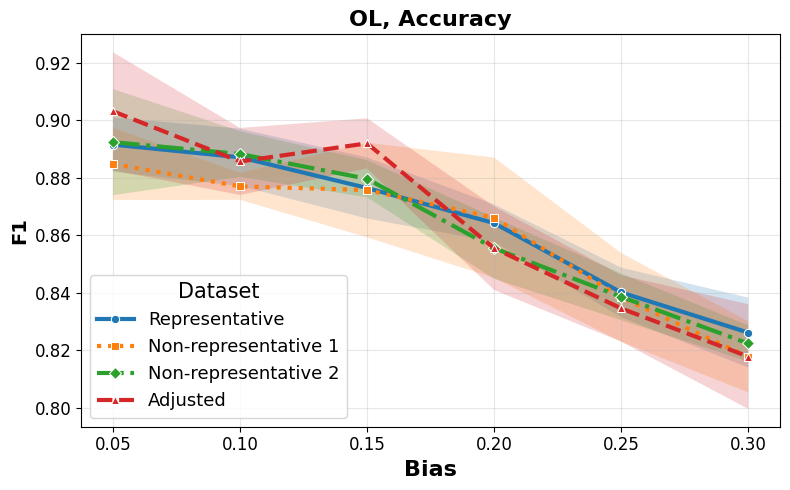

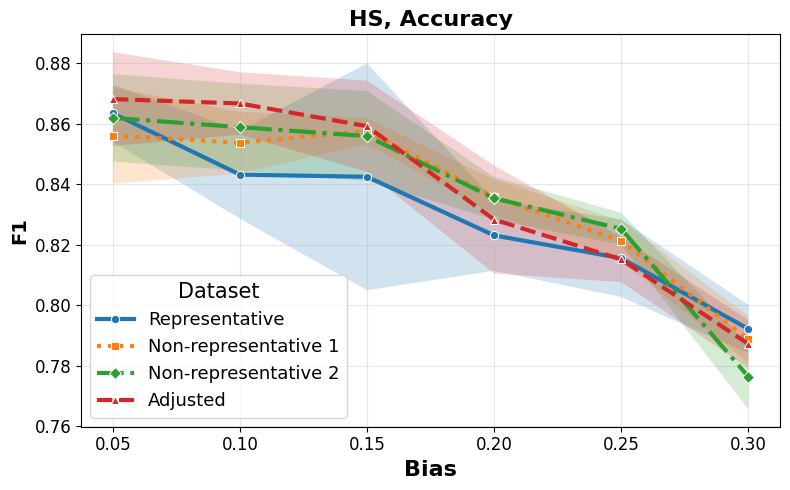

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
modes = ["bal", "unbal1", "unbal2", "adj"]
markers = {"bal": "o", "unbal1": "s", "unbal2": "D", "adj": "^"}
df = pd.read_csv("results/final_results_with_averages_f1.csv")

# Load four dataframes
df1 = pd.read_csv("results/results_f1_10.csv")
df2 = pd.read_csv("results/results_f1_42.csv")
df3 = pd.read_csv("results/results_f1_512.csv")
df4 = pd.read_csv("results/results_f1_1010.csv")
df5 = pd.read_csv("results/results_f1_3344.csv")

# Combine the dataframes into one and calculate mean and standard deviation
df_combined = pd.concat([df1, df2, df3, df4, df5])
df_grouped = df_combined.groupby(['L', 'mode', 'X']).agg(
    simulations_mean=('simulations', 'mean'),
    simulations_std=('simulations', 'std')
).reset_index()

# Map mode names for better readability
mode2name = {
    "bal": "Representative",
    "unbal1": "Non-representative 1",
    "unbal2": "Non-representative 2",
    "adj": "Adjusted",
}
# Define unique line styles for each mode
mode2style = {
    "bal": "solid",     # Balanced
    "unbal1": "dotted", # Unbalanced 1
    "unbal2": "dashdot",# Unbalanced 2
    "adj": "dashed"     # Adjusted
}

# Define the L values to plot
L_values = ["ol", "hs"]

for L in L_values:
    # Create a new figure for each L
    fig, ax = plt.subplots(figsize=(8, 5))

    # Filter data for current "L"
    df_filtered = df_grouped[df_grouped['L'] == L]

    # Sort modes
    modes = ["bal", "unbal1", "unbal2", "adj"]

    # Plot data for each mode
    for mode in modes:
        mode_data = df_filtered[df_filtered["mode"] == mode]

        # Plot mean line
        sns.lineplot(
            data=mode_data,
            x="X",
            y="simulations_mean",
            label=mode2name.get(mode, mode),
            marker=markers[mode],
            linewidth=3,
            ax=ax,
            linestyle=mode2style[mode]  # Apply specific line style
        )

        # Add standard deviation range (shades)
        ax.fill_between(
            mode_data["X"],
            mode_data["simulations_mean"] - mode_data["simulations_std"],
            mode_data["simulations_mean"] + mode_data["simulations_std"],
            alpha=0.2
        )

    # Customize subplot appearance
    ax.set_title(f"{L.upper()}, Accuracy", fontsize=16, fontweight='bold')
    ax.set_ylabel("F1", fontsize=14, fontweight='bold')
    ax.set_xlabel("Bias", fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid(alpha=0.3)
    ax.legend(title="Dataset", fontsize=13, title_fontsize=15)

    # Adjust layout and save the plot
    plt.tight_layout()
    plt.savefig(f"results/f1_{L}.pdf")
    plt.show()

### ACB

In [13]:
# simple bias, transpnsed
import pandas as pd
from sklearn.metrics import f1_score, brier_score_loss
import numpy as np

def compute_acb(true_probs, predicted_probs):
    """
    Compute abs(avg(true_probs) - avg(predicted_probs))
    """
    predicted_probs = np.array(predicted_probs)
    true_probs = np.array(true_probs)

    # Compute the averages
    avg_true = np.mean(true_probs)
    avg_predicted = np.mean(predicted_probs)
    
    # Return the absolute difference
    return abs(avg_true - avg_predicted)

SEEDs = [10, 42, 512, 1010, 3344]

for seed in SEEDs:
    # Initialize CSV file with the desired columns
    output_file = f'results/results_acb_{seed}.csv'
    columns = ['L', 'X', "mode",'simulations', 'len_data']
    df = pd.DataFrame(columns=columns)
    df.to_csv(output_file, index=False)

    modes=['bal', 'unbal1', 'unbal2', 'adj']


    # Iterate over values of L and X and append results to the CSV file
    for L in ["hs", "ol"]:
        for X in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
            for mode in modes:
                test = pd.read_csv(f"test_results/new_gold_{seed}.csv")
                test = test[test['x'] == X]
            
                if L == "hs":
                    label = "hate.speech"
                else:
                    label = "offensive.language"

                # Calculate balanced scores

                simulations = compute_acb(test[f"new_{L}_p"], test[f"results_{mode}_{L}_p"])
                len_data = len(test)
                
                # Append the results to the CSV file
                new_row = {
                    'L': L, 'X': X, "mode": mode,
                    #'a_bias': a_bias,
                    #'b_bias': b_bias,
                    'simulations': simulations,
                    #'gold': gold,
                    'len_data': len_data,
                }
                
                df = pd.DataFrame([new_row])
                df.to_csv(output_file, mode='a', header=False, index=False)  # Append without the header

In [14]:
import pandas as pd
import glob

# File paths: assume all result files are stored in one folder
file_paths = glob.glob("results/*.csv")

# Read all CSV files into a list (only those containing "results_acb" in the filename)
dfs = [pd.read_csv(file) for file in file_paths if "results_acb" in file]

# Make sure all DataFrames have the same column structure
for i, df in enumerate(dfs):
    if not dfs[0].columns.equals(df.columns):
        raise ValueError(f"The columns of CSV file {i+1} do not match the first file")

# Columns to be averaged
columns_to_average = ["simulations", "len_data"]

# Other columns that should not be averaged
all_other_columns = [col for col in dfs[0].columns if col not in columns_to_average]

# Lists to store intermediate results
average_data = []
non_average_data = []

# Extract required columns from each file
for df in dfs:
    average_data.append(df[columns_to_average])
    non_average_data.append(df[all_other_columns])

# Combine columns that need averaging
average_combined = pd.concat(average_data)

# Compute mean values grouped by row index (same rows across seeds)
average_result = average_combined.groupby(average_combined.index).mean()

# Extract other columns (assumed identical across files)
non_average_result = non_average_data[0]  # keep non-averaged columns from the first file

# Merge averaged columns with other columns
final_result = pd.concat(
    [non_average_result.reset_index(drop=True), average_result.reset_index(drop=True)],
    axis=1
)

# Save to a new CSV file
final_result.to_csv("results/final_results_with_averages_acb.csv", index=False)

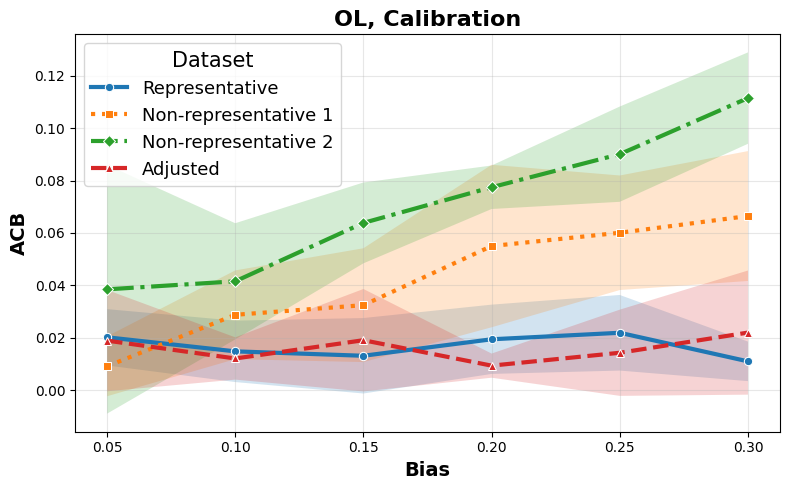

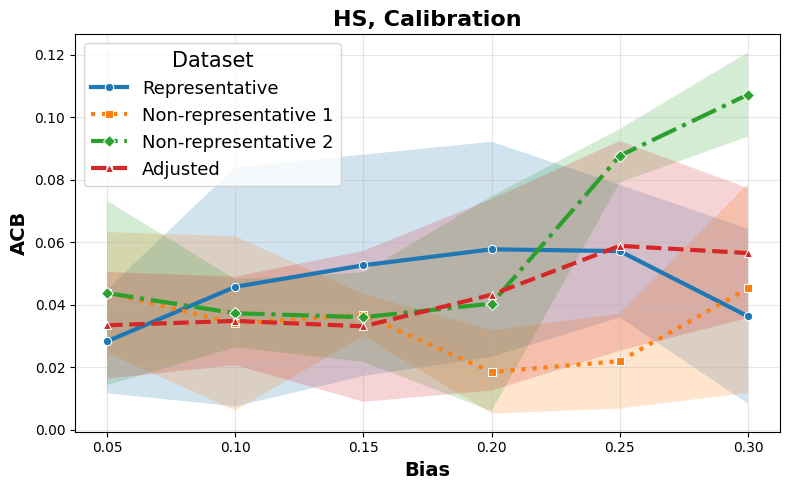

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load four dataframes
df1 = pd.read_csv("results/results_acb_10.csv")
df2 = pd.read_csv("results/results_acb_42.csv")
df3 = pd.read_csv("results/results_acb_512.csv")
df4 = pd.read_csv("results/results_acb_1010.csv")
df5 = pd.read_csv("results/results_acb_3344.csv")

# Combine the dataframes into one and calculate mean and standard deviation
df_combined = pd.concat([df1, df2, df3, df4, df5])
df_grouped = df_combined.groupby(['L', 'mode', 'X']).agg(
    simulations_mean=('simulations', 'mean'),
    simulations_std=('simulations', 'std')
).reset_index()

# Map mode names for better readability
mode2name = {
    "bal": "Representative",
    "unbal1": "Non-representative 1",
    "unbal2": "Non-representative 2",
    "adj": "Adjusted",
}
# Define unique line styles for each mode
mode2style = {
    "bal": "solid",     # Representative
    "unbal1": "dotted", # Non-representative 1
    "unbal2": "dashdot",# Non-representative 2
    "adj": "dashed"     # Adjusted
}


modes = ["bal", "unbal1", "unbal2", "adj"]
markers = {"bal": "o", "unbal1": "s", "unbal2": "D", "adj": "^"}

for L in ["ol", "hs"]:
    fig, ax = plt.subplots(figsize=(8, 5))  # 单独创建一个 figure

    # 过滤数据
    df_filtered = df_grouped[df_grouped['L'] == L]

    # 排序 mode
    modes = ["bal", "unbal1", "unbal2", "adj"]

    # 绘制每种 mode 的曲线
    for mode in modes:
        mode_data = df_filtered[df_filtered["mode"] == mode]

        sns.lineplot(
            data=mode_data,
            x="X",
            y="simulations_mean",
            label=mode2name.get(mode, mode),
            #marker="o",
            marker=markers[mode],
            linewidth=3,
            ax=ax,
            linestyle=mode2style[mode]  # 应用不同的线型
        )

        ax.fill_between(
            mode_data["X"],
            mode_data["simulations_mean"] - mode_data["simulations_std"],
            mode_data["simulations_mean"] + mode_data["simulations_std"],
            alpha=0.2
        )

    # 设置标题和标签
    ax.set_title(f"{L.upper()}, Calibration", fontsize=16, fontweight='bold')
    ax.set_xlabel("Bias", fontsize=14, fontweight='bold')
    ax.set_ylabel("ACB", fontsize=14, fontweight='bold')
    ax.legend(title="Dataset", fontsize=13, title_fontsize=15)
    ax.grid(alpha=0.3)

    # 保存单独的图
    plt.tight_layout()
    plt.savefig(f"results/acb_{L}.pdf")
    plt.show()
